# Topic Modelling
(Francesca)

In this notebook, I explore topic modeling using Latent Dirichlet Allocation (LDA) on a set of documents that include subtitles from 17 Disney and 17 Studio Ghibli movies. Topic modelling is performed on 102 documents for each movie studio. The number of documents was increased by splitting each movie into 6 parts of equal size, which aims to improve the performance of the model. 

The goal is to identify the main topics present in the subtitles and compare the topics between the two studios.

---

The notebook is structured as follows:

1. **Disney Topic Modelling**  
   1.1 Preprocessing of the Disney data  
   1.2 Document-term matrix  
   1.3 Apply the LDA model  
   1.4 Examine the topics  
   1.5 Visualize the topics  

2. **Studio Ghibli Topic Modelling**  
   2.1 Preprocessing of the Studio Ghibli data  
   2.2 Document-term matrix  
   2.3 Apply the LDA model  
   2.4 Examine the topics  
   2.5 Visualize the topics  

3. **Comparison between LDA Disney and LDA Studio Ghibli**  
   3.1 Comparison of Coherence Scores  
   3.2 Comparison of Topics  


References:
1. ChatGPT: https://chatgpt.com/share/6826fc0b-ea4c-800e-8f39-9801942680cf
2. Notebook: https://github.com/bloemj/AUC_TM_2025/blob/main/notebooks/12_Clustering_TopicModelling.ipynb

### Imports Libraries and Stopwords

#### Imports

In [11]:
# Imports

# Preprocessing imports
import os
import nltk
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from Stopwords_for_lda import stopwords_mallet, disney_main_characters, custom_movie_words, ghibli_main_characters

# Document-matrix imports
from gensim import corpora
import itertools
from collections import Counter
from gensim import models
from gensim.models.ldamodel import LdaModel

# Evaluation imports
from gensim.models import CoherenceModel

# Visualization imports
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Only Run once
nltk.download('wordnet') 
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset', download_dir='/home/codespace/nltk_data')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Stopwords:

In [13]:
# Stopwords for Disney
disney_main_characters = {
    "abby_mallard", "aladdin", "andy", "anna", "ariel", "beast", "belle", "bellwether", "blue_fairy",
    "bo_peep", "bogo", "buck_cluck", "bunny", "buzz", "calhoun", "chicken_little", "chip", "clawhauser",
    "cogsworth", "cobra_bubbles", "david", "duke", "dumbo", "elephant", "elsa", "eric", "felix", "fish",
    "flash", "flit", "flounder", "flynn", "gaston", "genie", "geppetto", "gothel", "gramma_tala",
    "grandmother_willow", "hades", "hamm", "hans", "hei_hei", "hercules", "honest_john", "iago", "jafar",
    "jasmine", "jessie", "jiminy", "jiminy_cricket", "john", "john_smith", "judy", "jumba", "knowsmore",
    "lefou", "lilo", "lumiere", "maximus", "meeko", "megara", "moana", "mr_big", "mrs_jumbo", "mrs_potts",
    "maui", "mufasa", "nakoma", "nala", "nani", "nick", "olaf", "pain", "panic", "pascal", "phil", "pinocchio",
    "pleakley", "pocahontas", "potato_head", "pua", "pumbaa", "rafiki", "ralph", "rapunzel", "ratcliffe",
    "rex", "ringmaster", "runt", "sultan", "scar", "scuttle", "sebastian", "shank", "simba", "slinky",
    "spamley", "stitch", "stromboli", "sven", "tamatoa", "te_fiti", "timothy", "timon", "toy", "triton",
    "ursula", "vanellope", "woody", "yesss", "zazu", "zeus"
}


In [14]:
# Stopwords for Studio Ghibli

ghibli_main_characters = {
    'αrchmage', ' τenar', 'arrietty', 'arren', 'ashitaka', 'asbel', 'anna',
    'chihiro', 'cob', 'eboshi', 'fio', 'ged', 'haku', 'haνe', 'heron', 'jiji', 'jiro',
    'kiki', 'laputa', 'lisa', 'mahito', 'marnie', 'mei', 'naoko', 'nausicaa', 'natsuko',
    'no_face', 'pazu', 'ponyo', 'porco', 'room', 'san', 'satsuki', 'seiji', 'seita',
    'setsuko', 'sheeta', 'shizuku', 'sho', 'shun', 'sparrowhawk', 'sosuke', 'taeko',
    'tenar', 'tombo', 'totoro', 'umi', 'yubaba', 'τherru'
}


In [15]:
# Stopwords from standard-mallet-en.txt
stopwords_mallet = {
    "a", "able", "about", "above", "according", "accordingly", "across", "actually", "after", "afterwards",
    "again", "against", "all", "allow", "allows", "almost", "alone", "along", "already", "also", "although",
    "always", "am", "among", "amongst", "an", "and", "another", "any", "anybody", "anyhow", "anyone",
    "anything", "anyway", "anyways", "anywhere", "apart", "appear", "appreciate", "appropriate", "are",
    "around", "as", "aside", "ask", "asking", "associated", "at", "available", "away", "awfully", "b", "be",
    "became", "because", "become", "becomes", "becoming", "been", "before", "beforehand", "behind", "being",
    "believe", "below", "beside", "besides", "best", "better", "between", "beyond", "big" "both", "brief", "but",
    "by", "c", "came", "can", "cannot", "cant", "cause", "causes", "certain", "certainly", "changes", "clearly",
    "co", "com", "come", "comes", "concerning", "consequently", "consider", "considering", "contain",
    "containing", "contains", "corresponding", "could", "course", "currently", "d", "definitely", "described",
    "despite", "did", "different", "do", "does", "doing", "done", "down", "downwards", "during", "e", "each",
    "edu", "eg", "eight", "either", "else", "elsewhere", "enough", "entirely", "especially", "et", "etc", "even",
    "ever", "every", "everybody", "everyone", "everything", "everywhere", "ex", "exactly", "example", "except",
    "f", "far", "few", "fifth", "first", "five", "followed", "following", "follows", "for", "former", "formerly",
    "forth", "four", "from", "further", "furthermore", "g", "get", "gets", "getting", "given", "gives", "go", "gonna"
    "goes", "going", "gone", "got", "gotten", "greetings", "h", "had", "happens", "hardly", "has", "have",
    "having", "he", "hello", "help", "hence", "her", "here", "hereafter", "hereby", "herein", "hereupon",
    "hers", "herself", "hi", "him", "himself", "his", "hither", "hopefully", "how", "howbeit", "however", "i",
    "ie", "if", "ignored", "immediate", "in", "inasmuch", "inc", "indeed", "indicate", "indicated", "indicates",
    "inner", "insofar", "instead", "into", "inward", "is", "it", "its", "itself", "j", "just", "k", "kind", "keep", "keeps",
    "kept", "know", "knows", "known", "l", "last", "lately", "later", "latter", "latterly", "least", "less", "lest",
    "let", "like", "liked", "likely", "little", "look", "looking", "looks", "ltd", "m", "mainly", "many", "may",
    "maybe", "me", "mean", "meanwhile", "merely", "might", "more", "moreover", "most", "mostly", "much",
    "must", "my", "myself", "n", "name", "namely", "nd", "near", "nearly", "necessary", "need", "needs",
    "neither", "never", "nevertheless", "new", "next", "nine", "no", "nobody", "non", "none", "noone", "nor",
    "normally", "not", "nothing", "novel", "now", "nowhere", "o", "obviously", "of", "off", "often", "oh", "ok",
    "okay", "old", "on", "once", "one", "ones", "only", "onto", "or", "other", "others", "otherwise", "ought",
    "our", "ours", "ourselves", "out", "outside", "over", "overall", "own", "p", "particular", "particularly",
    "per", "perhaps", "placed", "please", "plus", "possible", "presumably", "probably", "provides", "q",
    "que", "quite", "qv", "r", "rather", "rd", "re", "really", "reasonably", "regarding", "regardless",
    "regards", "relatively", "respectively", "right", "s", "said", "same", "saw", "say", "saying", "says",
    "second", "secondly", "see", "seeing", "seem", "seemed", "seeming", "seems", "seen", "self", "selves",
    "sensible", "sent", "serious", "seriously", "seven", "several", "shall", "she", "should", "since", "six",
    "so", "some", "somebody", "somehow", "someone", "something", "sometime", "sometimes", "somewhat",
    "somewhere", "soon", "sorry", "specified", "specify", "specifying", "still", "sub", "such", "sup", "sure",
    "t", "take", "taken", "tell", "tends", "th", "than", "thank", "thanks", "thanx", "that", "thats", "the",
    "their", "theirs", "them", "themselves", "then", "thence", "there", "thereafter", "thereby", "therefore",
    "therein", "theres", "thereupon", "these", "they", "think", "third", "this", "thorough", "thoroughly",
    "those", "though", "three", "through", "throughout", "thru", "thus", "to", "together", "too", "took",
    "toward", "towards", "tried", "tries", "truly", "try", "trying", "twice", "two", "u", "un", "under",
    "unfortunately", "unless", "unlikely", "until", "unto", "up", "upon", "us", "use", "used", "useful",
    "uses", "using", "usually", "uucp", "v", "value", "various", "very", "via", "viz", "vs", "w", "wait", "want",
    "wants", "was", "way", "we", "welcome", "well", "went", "were", "what", "whatever", "when", "whence",
    "whenever", "where", "whereafter", "whereas", "whereby", "wherein", "whereupon", "wherever",
    "whether", "which", "while", "whither", "who", "whoever", "whole", "whom", "whose", "why", "will",
    "willing", "wish", "with", "within", "without", "wonder", "whoa", "would", "x", "y", "yes", "yet", "you", "your",
    "yours", "yourself", "yourselves", "yeah", "z", "zero"
}


In [16]:
# Custom stopwords for movies

custom_movie_words = {
    "αnd", "actor", "animation", "animator", "animator", "animator", "animator", "anime", "bit", "boy", "case", "character",
    "computer", "day", "disney", "effect", "film", "frame", "gina", "ghibli", "girl", "gonna", "granduncle", "grasp",
    "grunt", "guy", "hey", "hopps", "howard", "huh", "hurry", "idea", "japan", "japanse", "line", "lot", "mei",
    "minute", "moment", "movie", "pig", "point", "second", "scene", "sequence", "sir", "song", "story", "studio",
    "studio_ghibli", "term", "thing", "things", "time", "voice", "αrren"
}


## 1. DISNEY TOPIC MODELLING  

### 1.1 Preprocessing of the Disney data

The following code performs the prepocessing for the corpus of Disney movie scripts. 
1. Load Data: The documents are loaded from the data_split/disney directory, which is tokenized into word-level representations.
2. Lemmatization: Each token is lemmatized with Part-of-Speech (POS) awareness, using a mapping from the Universal POS tagset to WordNet-compatible tags.
3. Filtering: Tokens are filtered to remove common stopwords, names of main Disney characters, and domain-specific movie terms. Only nouns and adjectives longer than two characters are retained for further analysis.

In [20]:
# Import Data
disney_data_folder = 'data_split/disney'

In [21]:
# WordNetLemmatizer, POS tags and stop words
un2wn_mapping = {"VERB": wn.VERB, "NOUN": wn.NOUN, "ADJ": wn.ADJ, "ADV": wn.ADV}
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Filtering function
def disney_filter_token(token):
    return token not in stopwords_mallet and token not in disney_main_characters and token not in custom_movie_words

In [24]:
# Creation of word lists (raw_documents) and the filenames (document_names) for final visualization

disney_raw_documents = []
disney_document_names = []

for filename in sorted(os.listdir(disney_data_folder)):  
    file_path = os.path.join(disney_data_folder, filename)
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            tokens = f.read().strip().split()
            disney_raw_documents.append(tokens)
            disney_document_names.append(filename)

In [25]:
# Lemmatize with POS tagging 
disney_movie_docs = []

for words in disney_raw_documents:
    disney_lemmatized_doc = []
    tagged = nltk.pos_tag(words, tagset="universal")
    for word, tag in tagged:
        if tag in un2wn_mapping:
            lemma = lemmatizer.lemmatize(word, pos=un2wn_mapping[tag])
        else:
            lemma = lemmatizer.lemmatize(word)
        lemma = lemma.lower()
        if disney_filter_token(lemma) and tag in {"NOUN", "ADJ"} and len(lemma) > 2: 
            disney_lemmatized_doc.append(lemma)
    disney_movie_docs.append(disney_lemmatized_doc)

print(f"Total documents: {len(disney_movie_docs)}")

Total documents: 102


### 1.2 Constuct a document-term matrix

In [26]:
# Create dictionary representation of documents
disney_movie_dictionary = corpora.Dictionary(disney_movie_docs)

# Filter out words that occur in less than 2 documents, or more than 80% of the documents.
disney_movie_dictionary.filter_extremes(no_below=2, no_above=0.8)
print('Number of unique tokens:', len(disney_movie_dictionary))

# Bag-of-words representation of the documents
disney_movie_bow_corpus = [disney_movie_dictionary.doc2bow(d) for d in disney_movie_docs]

Number of unique tokens: 2744


### 1.2 Apply the LDA model

In [27]:
disney_movie_ldamodel = models.ldamodel.LdaModel(disney_movie_bow_corpus, num_topics=5, id2word = disney_movie_dictionary, passes = 40)

### 1.3 Examine the topics

In [ ]:
# Top words in each topic (words and weights)
print(disney_movie_ldamodel.show_topics(formatted=False, num_words=8))

# Topic distribution for each document
for doc_topics in disney_movie_ldamodel.get_document_topics(disney_movie_bow_corpus):
    print(doc_topics)

### 1.4 Evaluate the model with Coherence Score

In [28]:
# Compute coherence score (how interpretable the topics are — higher is better)
disney_coherence_model_lda = CoherenceModel(
    model=disney_movie_ldamodel,
    texts=disney_movie_docs,
    dictionary=disney_movie_dictionary,
    coherence='c_v'  
)


### 1.5 Visualize the topics

Aladdin_cleaned_tokens_part1.txt: [7.21323129e-04 7.20233831e-04 7.25712278e-04 9.97111857e-01
 7.20836106e-04]
Aladdin_cleaned_tokens_part2.txt: [8.56415951e-04 8.61066277e-04 8.58536630e-04 9.96568024e-01
 8.55980616e-04]
Aladdin_cleaned_tokens_part3.txt: [9.34262120e-04 9.34122596e-04 9.34989890e-04 9.96266305e-01
 9.30352893e-04]
Aladdin_cleaned_tokens_part4.txt: [7.16143055e-04 9.94801939e-01 7.17432296e-04 3.04591027e-03
 7.18563388e-04]
Aladdin_cleaned_tokens_part5.txt: [7.98617955e-04 8.07242759e-04 7.99735950e-04 9.96792972e-01
 8.01447663e-04]
Aladdin_cleaned_tokens_part6.txt: [8.57250474e-04 8.61413544e-04 8.58952117e-04 9.96564806e-01
 8.57564213e-04]
Beauty.and.the.Beast_cleaned_tokens_part1.txt: [0.00105506 0.0010537  0.00105697 0.99577713 0.00105714]
Beauty.and.the.Beast_cleaned_tokens_part2.txt: [0.00107884 0.0010818  0.00109668 0.00109551 0.99564713]
Beauty.and.the.Beast_cleaned_tokens_part3.txt: [0.00119696 0.00120824 0.00121147 0.99518257 0.00120075]
Beauty.and.the.B

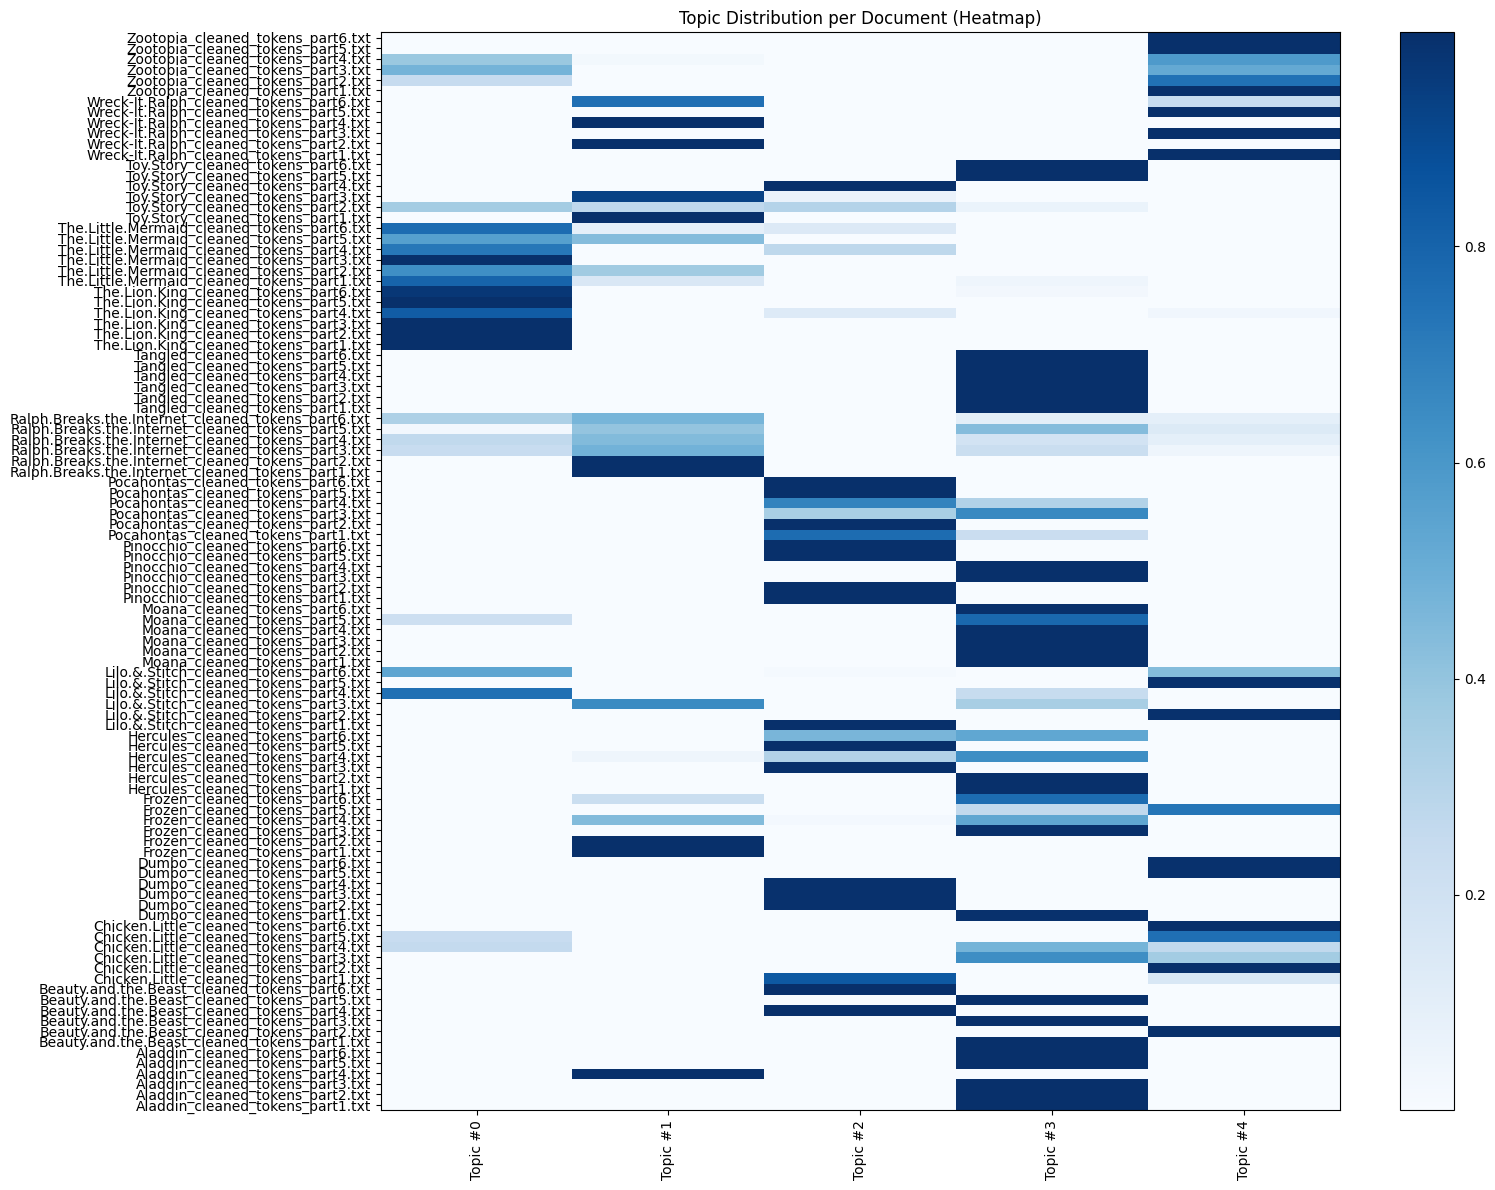

In [29]:
# Create a document-topic matrix: rows = documents, columns = topics
disney_doc2topics = np.zeros((len(disney_movie_docs), disney_movie_ldamodel.num_topics))

# Fill in topic probabilities for each document
for di, doc_topics in enumerate(disney_movie_ldamodel.get_document_topics(disney_movie_bow_corpus, minimum_probability=0)):
    for ti, v in doc_topics:
        disney_doc2topics[di, ti] = v

for i, doc_name in enumerate(disney_document_names):
    print(f"{doc_name}: {disney_doc2topics[i]}")

# Heatmap
disney_docs_id = disney_document_names
disney_num_topics = disney_movie_ldamodel.num_topics

fig = plt.figure(figsize=(16, 12))
plt.pcolor(disney_doc2topics, cmap='Blues')
plt.yticks(np.arange(disney_doc2topics.shape[0]) + 0.5, disney_docs_id, fontsize=10)
plt.xticks(np.arange(disney_num_topics) + 0.5, [f"Topic #{n}" for n in range(disney_num_topics)], rotation=90)
plt.colorbar()
plt.title("Topic Distribution per Document (Heatmap)")
plt.tight_layout()
plt.show()

In [ ]:
# Plot top words per topic

disney_fig = plt.figure(figsize=(16, 10))
num_top_words = 10


topic2top_words = dict(disney_movie_ldamodel.show_topics(formatted=False, num_words=num_top_words))
fontsize_base = 25 / max([w[0][1] for w in topic2top_words.values()])  

for topic, words_shares in topic2top_words.items():
    plt.subplot(1, disney_movie_ldamodel.num_topics, topic + 1)
    plt.ylim(0, num_top_words + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Topic #{topic}')
    for i, (word, share) in enumerate(words_shares):
        plt.text(0.3, num_top_words - i - 0.5, word, fontsize=fontsize_base * share)

plt.tight_layout()
plt.show()

## 2. Studio Ghibli Topic Modelling

### 2.1 Preprocessing of the Studio Ghibli data

The following code performs the prepocessing for the corpus of Disney movie scripts. 
1. Load Data: The documents are loaded from the data_split/ghibli directory, which is tokenized into word-level representations.
2. Lemmatization: Each token is lemmatized with Part-of-Speech (POS) awareness, using a mapping from the Universal POS tagset to WordNet-compatible tags.
3. Filtering: Tokens are filtered to remove common stopwords, names of main Disney characters, and domain-specific movie terms. Only nouns and adjectives longer than two characters are retained for further analysis.

In [ ]:
# Import data
ghibli_data_folder = 'data/data_split/ghibli'

In [ ]:
# WordNetLemmatizer, POS tags and stop words
un2wn_mapping = {"VERB": wn.VERB, "NOUN": wn.NOUN, "ADJ": wn.ADJ, "ADV": wn.ADV}
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Filtering function
def ghibli_filter_token(token):
    return token not in stopwords_mallet and token not in ghibli_main_characters and token not in custom_movie_words

In [ ]:
# Creation of word lists (raw_documents) and the filenames (document_names) for final visualization

ghibli_raw_documents = []
ghibli_document_names = []

for filename in sorted(os.listdir(ghibli_data_folder)):  
    file_path = os.path.join(ghibli_data_folder, filename)
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            tokens = f.read().strip().split()
            ghibli_raw_documents.append(tokens)
            ghibli_document_names.append(filename)

In [ ]:
# Lemmatize with POS awareness
ghibli_movie_docs = []

for words in ghibli_raw_documents:
    lemmatized_doc = []
    tagged = nltk.pos_tag(words, tagset="universal")
    for word, tag in tagged:
        if tag in un2wn_mapping:
            lemma = lemmatizer.lemmatize(word, pos=un2wn_mapping[tag])
        else:
            lemma = lemmatizer.lemmatize(word)
        lemma = lemma.lower()
        if ghibli_filter_token(lemma) and tag in {"NOUN"} and len(lemma) > 2: 
            lemmatized_doc.append(lemma)
    ghibli_movie_docs.append(lemmatized_doc)

print(f"Total documents: {len(ghibli_movie_docs)}")

### 2.1 Constuct a document-term matrix

In [ ]:
# Create dictionary representation of documents
ghibli_movie_dictionary = corpora.Dictionary(ghibli_movie_docs)

# Filter out words that occur in less than 2 documents, or more than 80% of the documents.
ghibli_movie_dictionary.filter_extremes(no_below=3, no_above=0.8)
print('Number of unique tokens:', len(ghibli_movie_dictionary))

# Bag-of-words representation of the documents
ghibli_movie_bow_corpus = [ghibli_movie_dictionary.doc2bow(d) for d in ghibli_movie_docs]


### 2.2 Apply the LDA model

In [ ]:
ghibli_movie_ldamodel = models.ldamodel.LdaModel(ghibli_movie_bow_corpus, num_topics=5, id2word = ghibli_movie_dictionary, passes = 40)

### 2.3 Examine the topics

In [ ]:
# Top words in each topic (words and weights)
print(ghibli_movie_ldamodel.show_topics(formatted=False, num_words=8))

# Topic distribution for each document
for doc_topics in ghibli_movie_ldamodel.get_document_topics(ghibli_movie_bow_corpus):
    print(doc_topics)

### 2.4 Evaluate the model with Coherence Score

In [ ]:
# Compute coherence score (how interpretable the topics are — higher is better)
ghibli_coherence_model_lda = CoherenceModel(
    model=ghibli_movie_ldamodel,
    texts=ghibli_movie_docs,
    dictionary=ghibli_movie_dictionary,
    coherence='c_v'  
)

print('\nCoherence score:', ghibli_coherence_model_lda.get_coherence())

# Compute coherence score for different number of topics
for k in range(2, 11):
    model = LdaModel(ghibli_movie_bow_corpus, num_topics=k, id2word=ghibli_movie_dictionary, passes=25)
    coherence = CoherenceModel(model=model, texts=ghibli_movie_docs, dictionary=ghibli_movie_dictionary, coherence='c_v').get_coherence()
    print(f"Topics: {k}, Coherence: {coherence:.4f}")

### 2.5 Visualize the topics

In [ ]:

# Create a document-topic matrix: rows = documents, columns = topics
ghibli_doc2topics = np.zeros((len(ghibli_movie_docs), ghibli_movie_ldamodel.num_topics))

# Fill in topic probabilities for each document
for di, doc_topics in enumerate(ghibli_movie_ldamodel.get_document_topics(ghibli_movie_bow_corpus, minimum_probability=0)):
    for ti, v in doc_topics:
        ghibli_doc2topics[di, ti] = v

for i, doc_name in enumerate(ghibli_document_names):
    print(f"{doc_name}: {ghibli_doc2topics[i]}")

# Heatmap
ghibli_docs_id = ghibli_document_names
ghibli_num_topics = ghibli_movie_ldamodel.num_topics

fig = plt.figure(figsize=(16, 12))
plt.pcolor(ghibli_doc2topics, cmap='Blues')
plt.yticks(np.arange(ghibli_doc2topics.shape[0]) + 0.5, ghibli_docs_id, fontsize=10)
plt.xticks(np.arange(ghibli_num_topics) + 0.5, [f"Topic #{n}" for n in range(ghibli_num_topics)], rotation=90)
plt.colorbar()
plt.title("Topic Distribution per Document (Heatmap)")
plt.tight_layout()
plt.savefig("ghibli_topic_heatmap.png", dpi=300)
plt.show()

In [ ]:
# Plot top words per topic

ghibli_fig = plt.figure(figsize=(16, 10))
num_top_words = 10


topic2top_words = dict(ghibli_movie_ldamodel.show_topics(formatted=False, num_words=num_top_words))
fontsize_base = 25 / max([w[0][1] for w in topic2top_words.values()])  

for topic, words_shares in topic2top_words.items():
    plt.subplot(1, ghibli_movie_ldamodel.num_topics, topic + 1)
    plt.ylim(0, num_top_words + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Topic #{topic}')
    for i, (word, share) in enumerate(words_shares):
        plt.text(0.3, num_top_words - i - 0.5, word, fontsize=fontsize_base * share)

plt.tight_layout()
plt.show()

## 3. Comparison between LDA Disney and LDA Studio Ghibli

### 3.1 Comparison of Coherence Scores

In [ ]:
# Coherence scores for Disney
disney_topics = list(range(2, 11))
disney_coherence = [0.2733, 0.2983, 0.3044, 0.3635, 0.3103, 0.3114, 0.3012, 0.3430, 0.3494]

# Coherence scores for Ghibli
ghibli_topics = list(range(2, 11))
ghibli_coherence = [0.2976, 0.3077, 0.3463, 0.3712, 0.3759, 0.3636, 0.4713, 0.4009, 0.4447]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(disney_topics, disney_coherence, marker='o', label='Disney', color='royalblue')
plt.plot(ghibli_topics, ghibli_coherence, marker='o', label='Ghibli', color='forestgreen')
plt.title('LDA Coherence Score Comparison: Disney vs. Ghibli')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2 Comparison of Topics